# Notebook 3 — AI Models I: Image Classification

**Digital Humanities · Image Processing for Museums & Cultural Heritage**

In Notebook 2 we saw that classic methods analyze *pixels*, not *meaning*.
Deep learning changed that: instead of writing rules, we show a neural
network millions of labeled examples and let it **learn** the rules.

In this notebook:

1. Use **pre-trained CNNs** (ResNet, VGG) to classify heritage images
2. Discover the **domain gap**: models trained on everyday photos meet art
3. **Grad-CAM**: see *where* the model looks when it decides
4. **CLIP zero-shot classification**: classify with *your own labels*,
   no training required — a superpower for museum collections
5. **Fine-tune** a model on your own data (`data/my_collection/`)

> ⏳ The first run downloads model weights (~100–600 MB total). They are
> cached, so later runs are fast.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import models, transforms

DATA = Path("..") / "data" / "raw"

# Pick the best available compute device
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 1. A pre-trained model in five lines

**ResNet-50** was trained on **ImageNet**: 1.2 million photos in 1,000
everyday categories (dog breeds, vehicles, household objects...).
Loading it gives us all of that learned visual knowledge for free.

In [6]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet = models.resnet50(weights=weights).to(device).eval()
preprocess = weights.transforms()           # the exact resizing/normalization it expects
categories = weights.meta["categories"]     # the 1,000 ImageNet class names
print(f"ResNet-50 loaded: {sum(p.numel() for p in resnet.parameters())/1e6:.0f}M parameters")

ResNet-50 loaded: 26M parameters


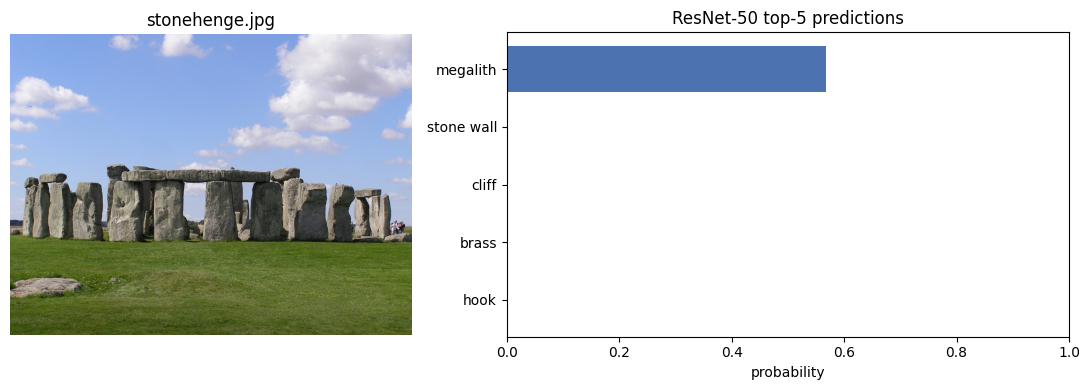

In [7]:
def classify(model, image: Image.Image, topk=5):
    """Return the model's top-k (probability, label) guesses for an image."""
    batch = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = model(batch).softmax(dim=1)[0]
    top = probs.topk(topk)
    return [(p.item(), categories[i]) for p, i in zip(top.values, top.indices)]

def show_classification(file, model=resnet):
    image = Image.open(DATA / file).convert("RGB")
    results = classify(model, image)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4),
                                   gridspec_kw={"width_ratios": [1, 1.4]})
    ax1.imshow(image); ax1.axis("off"); ax1.set_title(file)
    labels = [label for _, label in results][::-1]
    values = [p for p, _ in results][::-1]
    ax2.barh(labels, values, color="#4c72b0")
    ax2.set_xlim(0, 1); ax2.set_xlabel("probability")
    ax2.set_title("ResNet-50 top-5 predictions")
    plt.tight_layout(); plt.show()

show_classification("stonehenge.jpg")

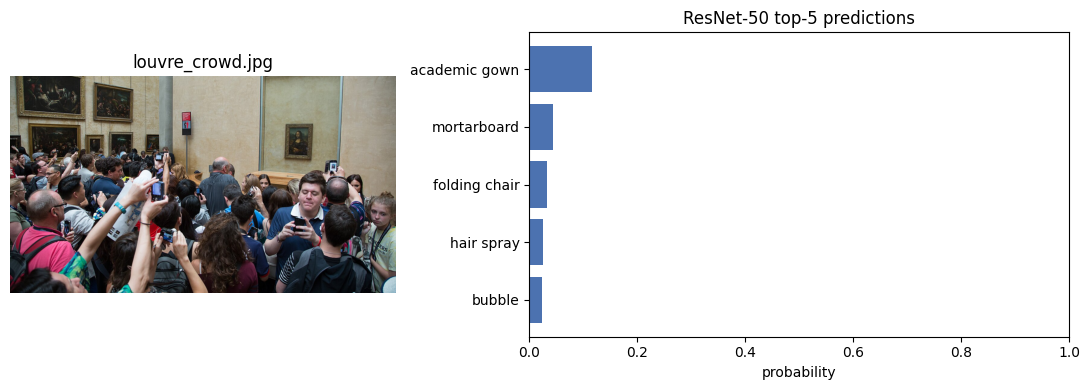

In [10]:
show_classification("louvre_crowd.jpg")

## 2. The domain gap: when everyday AI meets art

Now watch what happens with *paintings*:

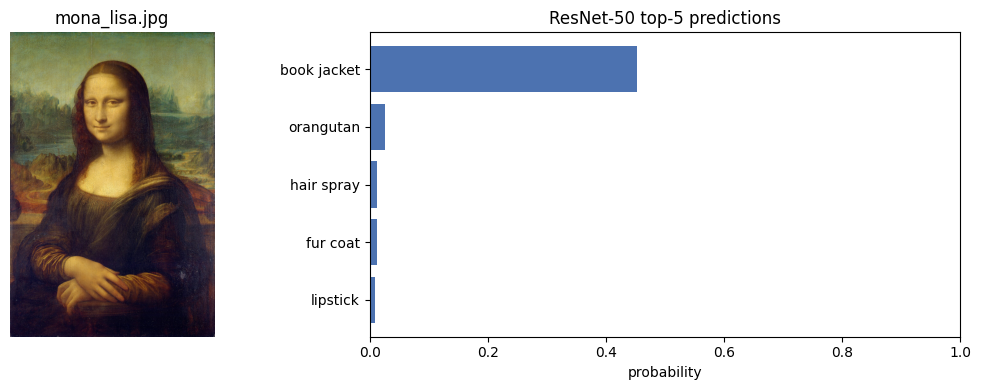

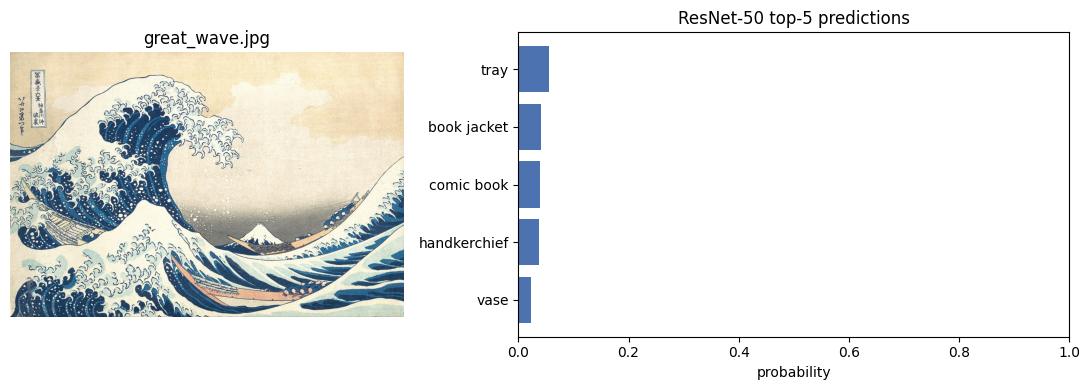

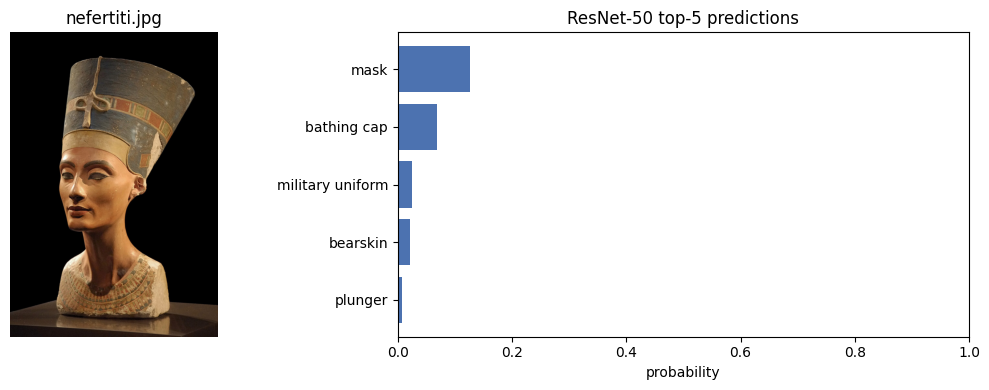

In [11]:
for file in ["mona_lisa.jpg", "great_wave.jpg", "nefertiti.jpg"]:
    show_classification(file)

The model answers confidently — but with ImageNet's vocabulary
("book jacket", "cliff", "mask"...). It has **never been told** what a
Renaissance portrait or an ukiyo-e print is. Three lessons:

1. A model only knows the **categories it was trained on**
2. Confidence ≠ correctness — models are confidently wrong outside their domain
3. For cultural heritage we need either **different labels** (→ CLIP, §4)
   or **retraining** (→ fine-tuning, §5)

This *domain gap* is one of the most important critical concepts in
Digital Humanities work with AI.

## 3. Grad-CAM: where does the model look?

**Grad-CAM** highlights the image regions that most influenced the model's
decision — turning the "black box" into something we can interrogate.

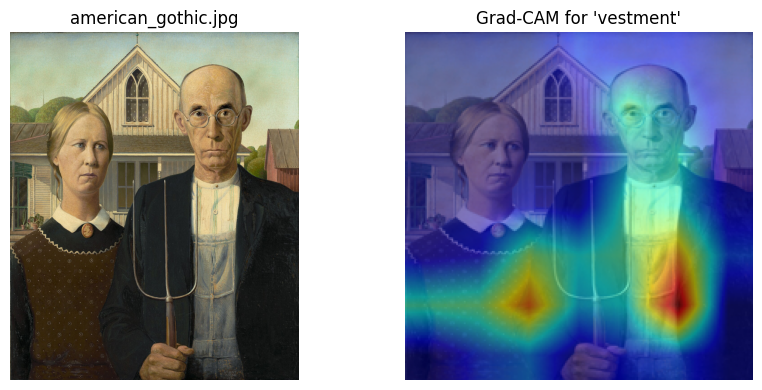

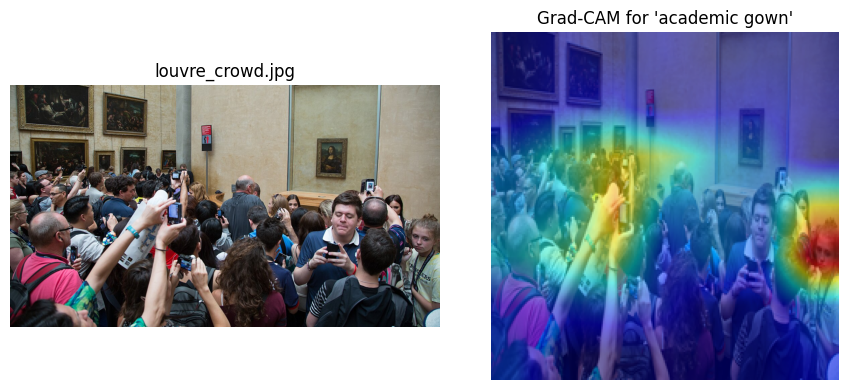

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def gradcam_view(file):
    image = Image.open(DATA / file).convert("RGB")
    batch = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        top_class = resnet(batch).argmax().item()

    cam = GradCAM(model=resnet, target_layers=[resnet.layer4[-1]])
    heat = cam(input_tensor=batch, targets=[ClassifierOutputTarget(top_class)])[0]

    # overlay the heatmap on the (resized) input image
    vis_img = np.array(image.resize((224, 224))) / 255.0
    overlay = show_cam_on_image(vis_img.astype(np.float32), heat, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(image); axes[0].set_title(file)
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM for '{categories[top_class]}'")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

gradcam_view("american_gothic.jpg")
gradcam_view("louvre_crowd.jpg")

## 4. CLIP: classification with *your* vocabulary

**CLIP** (OpenAI, 2021) was trained on 400 million image–text pairs from the
web. Instead of 1,000 fixed classes, it measures how well an image matches
**any text you write**. For museums this means instant, training-free
classification with curatorial vocabulary.

/Users/xkaria/anaconda3/envs/image-extractor-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


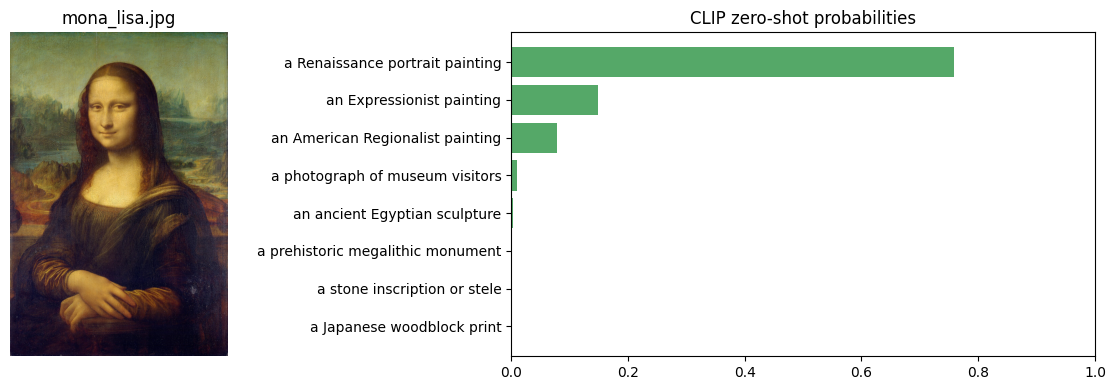

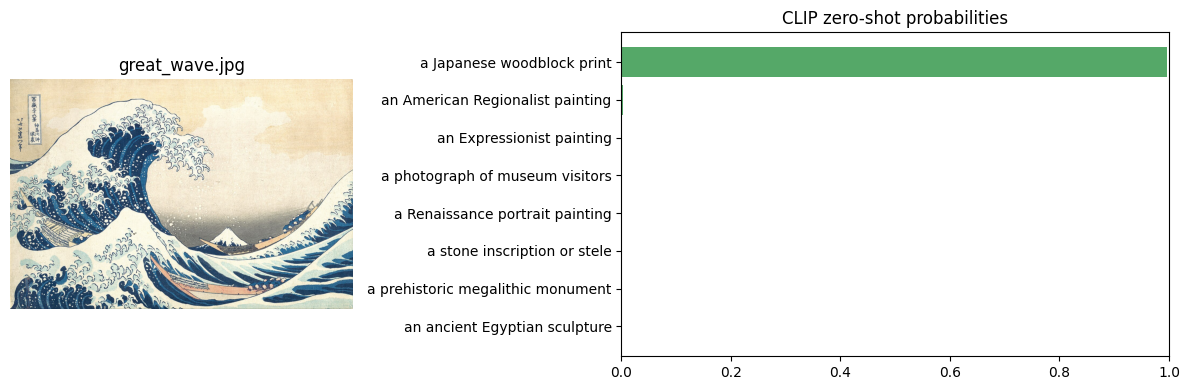

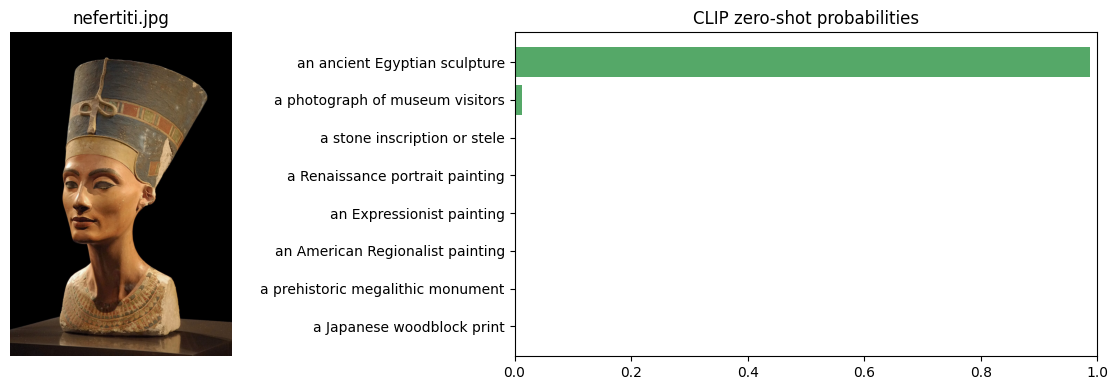

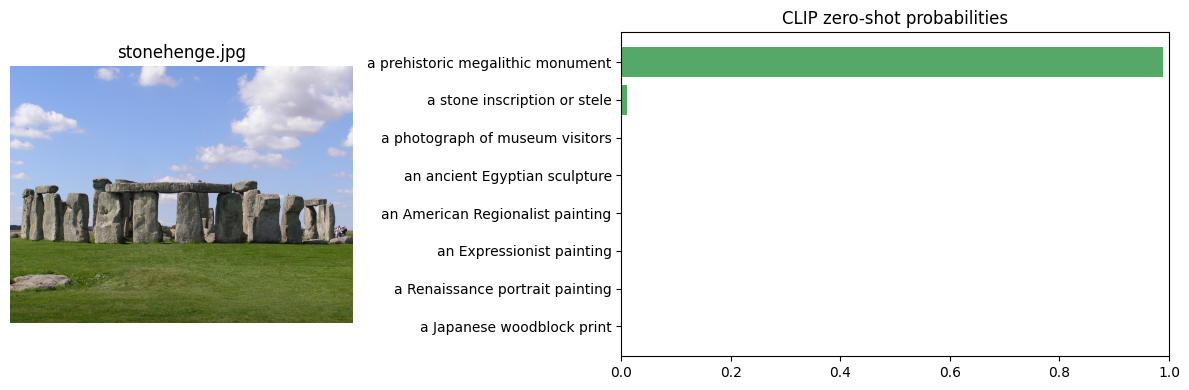

In [17]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

MUSEUM_LABELS = [
    "a Renaissance portrait painting",
    "a Japanese woodblock print",
    "an ancient Egyptian sculpture",
    "a stone inscription or stele",
    "a prehistoric megalithic monument",
    "an Expressionist painting",
    "a photograph of museum visitors",
    "an American Regionalist painting",
]

def clip_classify(file, labels=MUSEUM_LABELS):
    image = Image.open(DATA / file).convert("RGB")
    inputs = clip_processor(text=labels, images=image,
                            return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        probs = clip(**inputs).logits_per_image.softmax(dim=1)[0].cpu()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                                   gridspec_kw={"width_ratios": [1, 1.6]})
    ax1.imshow(image); ax1.axis("off"); ax1.set_title(file)
    order = probs.argsort()
    ax2.barh([labels[i] for i in order], probs[order], color="#55a868")
    ax2.set_xlim(0, 1); ax2.set_title("CLIP zero-shot probabilities")
    plt.tight_layout(); plt.show()

for f in ["mona_lisa.jpg", "great_wave.jpg", "nefertiti.jpg", "stonehenge.jpg"]:
    clip_classify(f)

Compare these results with ResNet's in §2: **same images, same AI era —
radically different usefulness**, because CLIP lets us bring our own
domain vocabulary. Try editing `MUSEUM_LABELS` — add periods, styles,
materials, even iconographic subjects ("an image of the Madonna and Child").

## 5. Fine-tuning: teaching a model *your* collection

Zero-shot is great, but sometimes you need a model trained for **your**
specific task: classifying *your* archive's photo types, *your* pottery
shards, *your* manuscript hands. The standard recipe is **transfer
learning**: take a pre-trained network, freeze its visual knowledge, and
retrain only the final layer on your (small) dataset.

### Using your own data
Put images into class-named subfolders, then re-run this section:
```
data/my_collection/
├── paintings/      img001.jpg, img002.jpg, ...
├── sculptures/     ...
└── manuscripts/    ...
```
If `data/my_collection/` is empty, the cell below **builds a small demo
dataset automatically** (crops of our Wikimedia images in two classes:
`painting` vs `monument`), so the teaching demo always works.

In [18]:
import random
from torchvision import datasets

MY_DATA = Path("..") / "data" / "my_collection"

def build_demo_dataset(per_image=12, size=300):
    """Create a tiny 2-class dataset by sampling random crops from data/raw."""
    classes = {
        "painting": ["mona_lisa.jpg", "starry_night.jpg", "great_wave.jpg",
                     "the_scream.jpg", "american_gothic.jpg", "girl_pearl_earring.jpg"],
        "monument": ["rosetta_stone.jpg", "nefertiti.jpg", "stonehenge.jpg"],
    }
    rng = random.Random(0)
    for cls, files in classes.items():
        (MY_DATA / cls).mkdir(parents=True, exist_ok=True)
        for file in files:
            im = Image.open(DATA / file).convert("RGB")
            for k in range(per_image):
                x = rng.randint(0, im.width - size)
                y = rng.randint(0, im.height - size)
                im.crop((x, y, x + size, y + size)).save(
                    MY_DATA / cls / f"{file[:-4]}_{k}.jpg")
    print("Demo dataset created.")

if not any(p.is_dir() for p in MY_DATA.iterdir() if not p.name.startswith(".")):
    build_demo_dataset()

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
dataset = datasets.ImageFolder(MY_DATA, transform=train_tf)
print(f"{len(dataset)} images in classes: {dataset.classes}")

n_val = max(2, len(dataset) // 5)
train_set, val_set = torch.utils.data.random_split(
    dataset, [len(dataset) - n_val, n_val],
    generator=torch.Generator().manual_seed(0))
train_loader = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=16)

108 images in classes: ['monument', 'painting']


In [19]:
# Transfer learning: freeze ResNet-18's backbone, replace & train only the head
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            pred = model(x.to(device)).argmax(dim=1).cpu()
            correct += (pred == y).sum().item()
            total += len(y)
    print(f"epoch {epoch + 1}/{EPOCHS}  loss {loss.item():.3f}  "
          f"val accuracy {correct / total:.0%}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/xkaria/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 32.0MB/s]


epoch 1/5  loss 0.784  val accuracy 52%
epoch 2/5  loss 0.462  val accuracy 57%
epoch 3/5  loss 0.471  val accuracy 67%
epoch 4/5  loss 0.257  val accuracy 86%
epoch 5/5  loss 0.791  val accuracy 76%


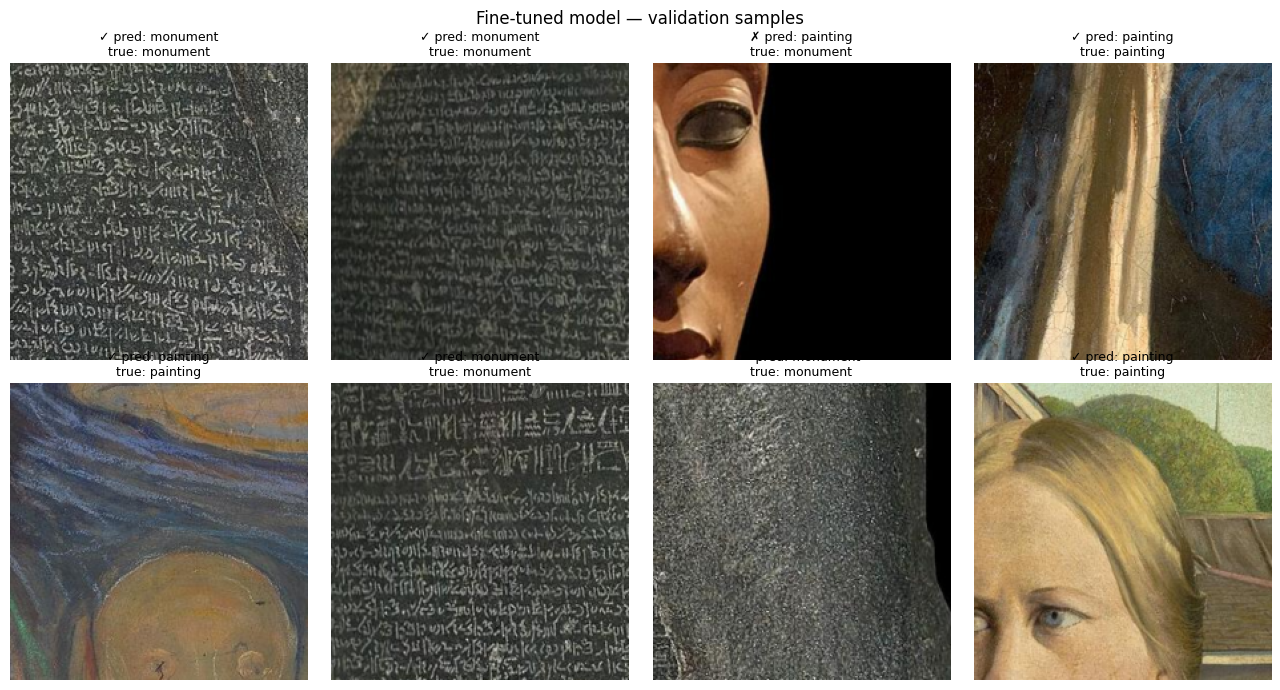

In [10]:
# Inspect some validation predictions
model.eval()
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
indices = random.Random(1).sample(range(len(val_set)), 8)
inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225])
for ax, i in zip(axes.flat, indices):
    x, y = val_set[i]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).argmax().item()
    ax.imshow(inv_norm(x).permute(1, 2, 0).clamp(0, 1))
    ok = "✓" if pred == y else "✗"
    ax.set_title(f"{ok} pred: {dataset.classes[pred]}\ntrue: {dataset.classes[y]}",
                 fontsize=9)
    ax.axis("off")
plt.suptitle("Fine-tuned model — validation samples")
plt.tight_layout(); plt.show()

With ~100 images and 5 epochs we built a working specialist classifier —
because the heavy lifting (learning what edges, textures, and shapes look
like) was already done by ImageNet pre-training. **This recipe scales
directly to real collections**: swap the demo folders for your own.

## ✏️ Exercises

1. Add a third class to the demo dataset (e.g. crops from
   `louvre_crowd.jpg` as class `museum_photo`) and retrain.
2. Write CLIP labels that distinguish the *five painting styles* in our
   sample set. How fine-grained can you get before CLIP fails?
3. Run Grad-CAM on a *misclassified* validation image. Where was the model
   looking, and does that explain the error?
4. Critical discussion: an ImageNet model labels Nefertiti's bust a "mask".
   What harms could mislabeling cause in a real museum catalog, and who
   should review AI-generated metadata?

**Next:** Notebook 4 — finding *multiple* objects in an image with
object detection (YOLO & Faster R-CNN), and exploring results in FiftyOne.